In [1]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split,cross_val_score,GridSearchCV
from sklearn.metrics import r2_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.preprocessing import OneHotEncoder, StandardScaler,MinMaxScaler

from sklearn.preprocessing import PolynomialFeatures

from sklearn.feature_selection import RFE

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("yasserh/housing-prices-dataset")

print("Path to dataset files:", path)
print(os.listdir(path))

Using Colab cache for faster access to the 'housing-prices-dataset' dataset.
Path to dataset files: /kaggle/input/housing-prices-dataset
['Housing.csv']


In [3]:
df = pd.read_csv(os.path.join(path, 'Housing.csv'))
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [4]:
df.shape

(545, 13)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB


In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.describe()

,price,area,bedrooms,bathrooms,stories,parking
count,5.450000e+02,545.000000,545.000000,545.000000,545.000000,545.000000
mean,4.766729e+06,5150.541284,2.965138,1.286239,1.805505,0.693578
std,1.870440e+06,2170.141023,0.738064,0.502470,0.867492,0.861586
min,1.750000e+06,1650.000000,1.000000,1.000000,1.000000,0.000000
25%,3.430000e+06,3600.000000,2.000000,1.000000,1.000000,0.000000
50%,4.340000e+06,4600.000000,3.000000,1.000000,2.000000,0.000000
75%,5.740000e+06,6360.000000,3.000000,2.000000,2.000000,1.000000
max,1.330000e+07,16200.000000,6.000000,4.000000,4.000000,3.000000


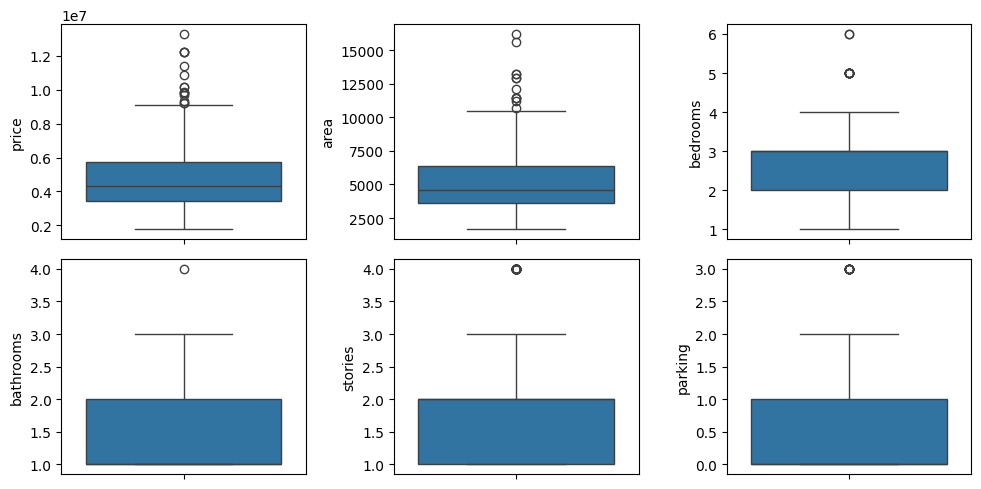

In [8]:
fig, axs = plt.subplots(2,3, figsize = (10,5))
plt1 = sns.boxplot(df['price'], ax = axs[0,0])
plt2 = sns.boxplot(df['area'], ax = axs[0,1])
plt3 = sns.boxplot(df['bedrooms'], ax = axs[0,2])
plt1 = sns.boxplot(df['bathrooms'], ax = axs[1,0])
plt2 = sns.boxplot(df['stories'], ax = axs[1,1])
plt3 = sns.boxplot(df['parking'], ax = axs[1,2])

plt.tight_layout()

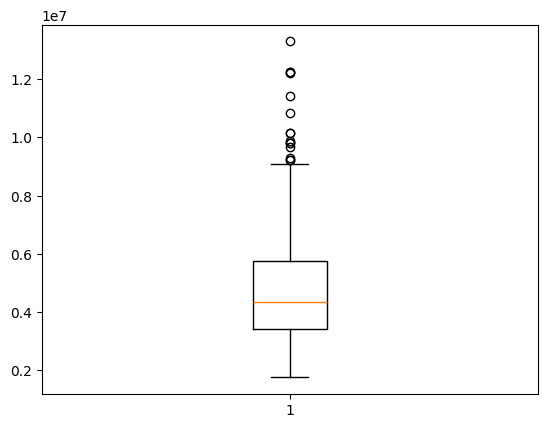

In [9]:
# outlier treatment for price
plt.boxplot(df.price)
Q1 = df.price.quantile(0.25)
Q3 = df.price.quantile(0.75)
IQR = Q3 - Q1
df= df[(df.price >= Q1 - 1.5*IQR) & (df.price <= Q3 + 1.5*IQR)]

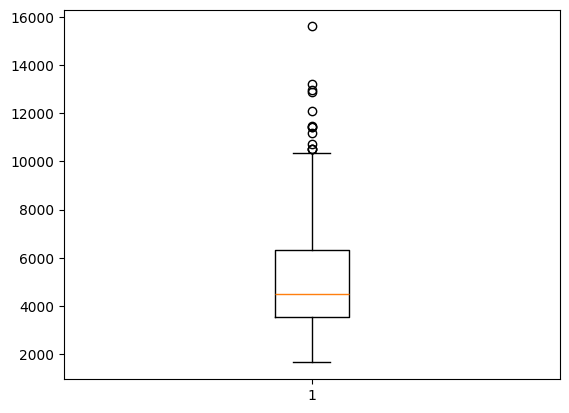

In [10]:
# outlier treatment for area
plt.boxplot(df.area)
Q1 = df.area.quantile(0.25)
Q3 = df.area.quantile(0.75)
IQR = Q3 - Q1
df = df[(df.area >= Q1 - 1.5*IQR) & (df.area <= Q3 + 1.5*IQR)]

In [11]:
binary_string_cols = [
    'mainroad', 'guestroom', 'basement', 'hotwaterheating',
    'airconditioning', 'prefarea'
]

for col in binary_string_cols:
    if col in df.columns:
        df[col] = df[col].map({'yes': 1, 'no': 0})

df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
15,9100000,6000,4,1,2,1,0,1,0,0,2,0,semi-furnished
16,9100000,6600,4,2,2,1,1,1,0,1,1,1,unfurnished
17,8960000,8500,3,2,4,1,0,0,0,1,2,0,furnished
18,8890000,4600,3,2,2,1,1,0,0,1,2,0,furnished
19,8855000,6420,3,2,2,1,0,0,0,1,1,1,semi-furnished


In [12]:
if 'furnishingstatus' in df.columns:
    df = pd.get_dummies(df, columns=['furnishingstatus'], prefix='furn', drop_first=True)
    bool_cols = df.select_dtypes(include=['bool']).columns
    df[bool_cols] = df[bool_cols].astype(int)

df.head()


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furn_semi-furnished,furn_unfurnished
15,9100000,6000,4,1,2,1,0,1,0,0,2,0,1,0
16,9100000,6600,4,2,2,1,1,1,0,1,1,1,0,1
17,8960000,8500,3,2,4,1,0,0,0,1,2,0,0,0
18,8890000,4600,3,2,2,1,1,0,0,1,2,0,0,0
19,8855000,6420,3,2,2,1,0,0,0,1,1,1,1,0


In [13]:
scaler =MinMaxScaler()
df_scaled = scaler.fit_transform(df)

df_scaled = pd.DataFrame(df_scaled, columns=df.columns)

df_scaled = df_scaled.round(5)


df_scaled.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furn_semi-furnished,furn_unfurnished
0,1.00000,0.49943,0.6,0.0,0.33333,1.0,0.0,1.0,0.0,0.0,0.66667,0.0,1.0,0.0
1,1.00000,0.56831,0.6,0.5,0.33333,1.0,1.0,1.0,0.0,1.0,0.33333,1.0,0.0,1.0
2,0.98095,0.78645,0.4,0.5,1.00000,1.0,0.0,0.0,0.0,1.0,0.66667,0.0,0.0,0.0
3,0.97143,0.33869,0.4,0.5,0.33333,1.0,1.0,0.0,0.0,1.0,0.66667,0.0,0.0,0.0
4,0.96667,0.54765,0.4,0.5,0.33333,1.0,0.0,0.0,0.0,1.0,0.33333,1.0,1.0,0.0


In [14]:
X = df_scaled.drop(columns=['price'])
Y = df_scaled['price']

In [15]:
X

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furn_semi-furnished,furn_unfurnished
0,0.49943,0.6,0.0,0.33333,1.0,0.0,1.0,0.0,0.0,0.66667,0.0,1.0,0.0
1,0.56831,0.6,0.5,0.33333,1.0,1.0,1.0,0.0,1.0,0.33333,1.0,0.0,1.0
2,0.78645,0.4,0.5,1.00000,1.0,0.0,0.0,0.0,1.0,0.66667,0.0,0.0,0.0
3,0.33869,0.4,0.5,0.33333,1.0,1.0,0.0,0.0,1.0,0.66667,0.0,0.0,0.0
4,0.54765,0.4,0.5,0.33333,1.0,0.0,0.0,0.0,1.0,0.33333,1.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
512,0.15499,0.2,0.0,0.00000,1.0,0.0,1.0,0.0,0.0,0.66667,0.0,0.0,1.0
513,0.08611,0.4,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,1.0,0.0
514,0.22618,0.2,0.0,0.00000,1.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,1.0
515,0.14466,0.4,0.0,0.00000,0.0,0.0,0.0,0.0,0.0,0.00000,0.0,0.0,0.0


In [16]:
Y

,price
0,1.00000
1,1.00000
2,0.98095
3,0.97143
4,0.96667
...,...
512,0.00952
513,0.00233
514,0.00000
515,0.00000


In [17]:
corr = X.corrwith(Y).abs().sort_values(ascending=False)
print(corr.head(10))

area                0.533188
airconditioning     0.471706
bathrooms           0.466483
stories             0.446839
bedrooms            0.335329
parking             0.321058
mainroad            0.307186
guestroom           0.303995
prefarea            0.280807
furn_unfurnished    0.278463
dtype: float64


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, Y , test_size=0.3, random_state=42)



In [19]:
X_train

,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furn_semi-furnished,furn_unfurnished
311,0.24455,0.2,0.0,0.33333,1.0,1.0,1.0,0.0,0.0,0.00000,0.0,1.0,0.0
368,0.22388,1.0,0.0,0.33333,1.0,0.0,0.0,0.0,0.0,0.33333,0.0,0.0,1.0
23,0.49943,0.4,0.0,1.00000,1.0,1.0,0.0,0.0,1.0,0.66667,0.0,0.0,1.0
271,0.47646,0.4,0.0,0.00000,1.0,0.0,0.0,1.0,0.0,0.66667,0.0,1.0,0.0
299,0.28129,0.6,0.0,0.00000,0.0,0.0,1.0,0.0,0.0,0.00000,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,0.58553,0.2,0.0,0.00000,1.0,1.0,1.0,0.0,0.0,0.66667,1.0,0.0,0.0
106,0.55683,0.4,0.5,0.66667,1.0,0.0,0.0,0.0,1.0,0.00000,0.0,0.0,1.0
270,0.22847,0.4,0.5,0.33333,1.0,0.0,1.0,0.0,0.0,0.00000,0.0,0.0,1.0
435,0.16533,0.2,0.0,0.00000,1.0,1.0,1.0,0.0,0.0,0.00000,0.0,0.0,1.0


Starting hyperparameter tuning...

lr=0.0050, epochs=500, lambda=0 -> Val MSE = 0.0138
lr=0.0050, epochs=500, lambda=0.001 -> Val MSE = 0.0141
lr=0.0050, epochs=500, lambda=0.01 -> Val MSE = 0.0144
lr=0.0050, epochs=500, lambda=0.1 -> Val MSE = 0.0147
lr=0.0050, epochs=1000, lambda=0 -> Val MSE = 0.0127
lr=0.0050, epochs=1000, lambda=0.001 -> Val MSE = 0.0130
lr=0.0050, epochs=1000, lambda=0.01 -> Val MSE = 0.0131
lr=0.0050, epochs=1000, lambda=0.1 -> Val MSE = 0.0136
lr=0.0050, epochs=2000, lambda=0 -> Val MSE = 0.0126
lr=0.0050, epochs=2000, lambda=0.001 -> Val MSE = 0.0128
lr=0.0050, epochs=2000, lambda=0.01 -> Val MSE = 0.0125
lr=0.0050, epochs=2000, lambda=0.1 -> Val MSE = 0.0134
lr=0.0050, epochs=5000, lambda=0 -> Val MSE = 0.0131
lr=0.0050, epochs=5000, lambda=0.001 -> Val MSE = 0.0131
lr=0.0050, epochs=5000, lambda=0.01 -> Val MSE = 0.0127
lr=0.0050, epochs=5000, lambda=0.1 -> Val MSE = 0.0135
lr=0.0100, epochs=500, lambda=0 -> Val MSE = 0.0131
lr=0.0100, epochs=500, lambda=0.0

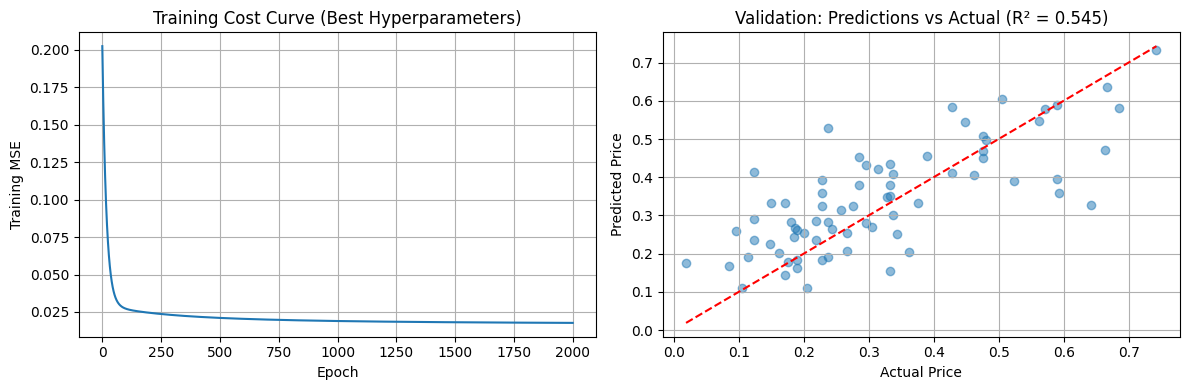

In [30]:


def predict(X, weights, bias):
    return np.dot(X, weights) + bias

def compute_cost(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)

def gradient_descent(X, y, weights, bias, lr, lambda_reg, epochs):
    m = len(y)
    cost_history = []
    for _ in range(epochs):
        y_pred = predict(X, weights, bias)
        error = y_pred - y

        dw = (2/m) * (X.T @ error) + 2 * lambda_reg * weights
        db = (2/m) * np.sum(error)

        weights -= lr * dw
        bias -= lr * db

        cost_history.append(compute_cost(y, y_pred))
    return weights, bias, cost_history


X_train_final, X_val, y_train_final, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)


learning_rates = [0.005, 0.01, 0.05,0.1]
epochs_list = [500,1000,2000, 5000]
lambda_regs = [0, 0.001,0.01,0.1]

best_val_mse = float('inf')
best_params = {}

print("Starting hyperparameter tuning...\n")

for lr in learning_rates:
    for epochs in epochs_list:
        for reg in lambda_regs:
            w = np.random.randn(X_train_final.shape[1]) * 0.01
            b = 0.0

            w_trained, b_trained, _ = gradient_descent(
                X_train_final, y_train_final, w, b, lr, reg, epochs
            )

            y_val_pred = predict(X_val, w_trained, b_trained)
            val_mse = compute_cost(y_val, y_val_pred)

            print(f"lr={lr:.4f}, epochs={epochs}, lambda={reg} -> Val MSE = {val_mse:.4f}")

            if val_mse < best_val_mse:
                best_val_mse = val_mse
                best_params = {
                    'learning_rate': lr,
                    'epochs': epochs,
                    'lambda_reg': reg
                }


print("\nBest hyperparameters found:")
print(best_params)

w_final = np.random.randn(X_train_final.shape[1]) * 0.01
b_final = 0.0

w_final, b_final, cost_history = gradient_descent(
    X_train_final, y_train_final,
    w_final, b_final,
    lr=best_params['learning_rate'],
    lambda_reg=best_params['lambda_reg'],
    epochs=best_params['epochs']
)


#  EVALUATE ON VALIDATION SET (MSE, RMSE, R²)

y_val_pred = predict(X_val, w_final, b_final)
val_mse = compute_cost(y_val, y_val_pred)
val_rmse = np.sqrt(val_mse)
val_r2 = r2_score(y_val, y_val_pred)

print("\n===== Validation Set Performance =====")
print(f"MSE:  {val_mse:.4f}")
print(f"RMSE: {val_rmse:.4f}")
print(f"R²:   {val_r2:.4f}")



y_test_pred = predict(X_test, w_final, b_final)
test_mse = compute_cost(y_test, y_test_pred)
test_rmse = np.sqrt(test_mse)
test_r2 = r2_score(y_test, y_test_pred)

print("\n===== Test Set Performance =====")
print(f"MSE:  {test_mse:.4f}")
print(f"RMSE: {test_rmse:.4f}")
print(f"R²:   {test_r2:.4f}")


plt.figure(figsize=(12, 4))

# Training cost curve
plt.subplot(1, 2, 1)
plt.plot(cost_history)
plt.xlabel('Epoch')
plt.ylabel('Training MSE')
plt.title('Training Cost Curve (Best Hyperparameters)')
plt.grid(True)

# Predictions vs actual (validation set)
plt.subplot(1, 2, 2)
plt.scatter(y_val, y_val_pred, alpha=0.5)
plt.plot([y_val.min(), y_val.max()], [y_val.min(), y_val.max()], 'r--')
plt.xlabel('Actual Price')
plt.ylabel('Predicted Price')
plt.title(f'Validation: Predictions vs Actual (R² = {val_r2:.3f})')
plt.grid(True)

plt.tight_layout()
plt.show()

In [21]:
y_train

,price
311,0.29048
368,0.23810
23,0.84524
271,0.33333
299,0.30476
...,...
71,0.63524
106,0.56190
270,0.33333
435,0.18095


In [22]:



model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)


r2 = r2_score(y_test, y_pred)

print("R2 Score :", r2)


R2 Score : 0.7101232622598593


In [23]:
model.get_params()

{'copy_X': True, 'fit_intercept': True, 'n_jobs': None, 'positive': False}

In [24]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import RandomizedSearchCV, cross_val_score
from scipy.stats import loguniform

# Hyperparameter distribution
param_dist = {'alpha': loguniform(1e-4, 1e5)}

# Create model and search
ridge = Ridge()
random_search = RandomizedSearchCV(ridge, param_dist, n_iter=30, cv=5,
                                   scoring='r2', random_state=42)
random_search.fit(X_train, y_train)

# Best model
best_ridge = random_search.best_estimator_
y_pred_tuned = best_ridge.predict(X_test)
print("Tuned R2:", r2_score(y_test, y_pred_tuned))
print("Best alpha:", random_search.best_params_['alpha'])

Tuned R2: 0.7068489099992197
Best alpha: 1.2724181576752527


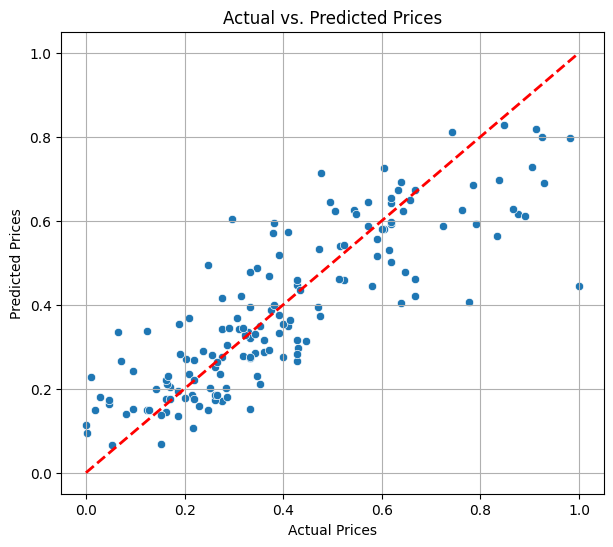

In [25]:
plt.figure(figsize=(7, 6))
sns.scatterplot(x=y_test, y=y_pred)
plt.plot([min(y_test), max(y_test)], [min(y_test), max(y_test)], color='red', linestyle='--', lw=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title('Actual vs. Predicted Prices')
plt.grid(True)
plt.show()

In [26]:
comparison_df = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})


comparison_df.head(20)

,Actual,Predicted
304,0.29524,0.602914
501,0.07143,0.266060
441,0.17143,0.204926
153,0.47524,0.374228
503,0.06571,0.334517
131,0.51429,0.539603
204,0.40000,0.275148
512,0.00952,0.227821
325,0.27619,0.274795
247,0.35238,0.350190
